# Besoin Client 3 – Système d'alerte pour les tempêtes

**Objectif :** prédire si un arbre est susceptible d'être déraciné lors d'une tempête, à partir de ses caractéristiques physiques et environnementales.

**Cible :** colonne `fk_arb_etat` recodée en binaire :
- `1` → arbre considéré déraciné : *Essouché*, *Non essouché*, et *ABATTU* sans date d'abattage
- `0` → arbre non déraciné : tous les autres états

Les arbres *ABATTU* sans date d'abattage sont inclus dans les positifs car l'absence de date suggère un abattage d'urgence potentiellement lié à une tempête.

Le modèle utilise un **seuil de décision à 50%** : si la probabilité estimée de déracinement dépasse 50%, l'arbre est classé à risque.

## 1. Chargement des données

In [1]:
import pandas as pd

df = pd.read_csv('Data_Arbre_Clean.csv')
print(f'Shape : {df.shape}')
print(df['fk_arb_etat'].value_counts())

Shape : (11248, 37)
fk_arb_etat
EN PLACE        10221
SUPPRIMÉ          448
Essouché          206
REMPLACÉ          188
ABATTU            114
Non essouché       62
Name: count, dtype: int64


## 2. Préparation des données

### 2.1 Construction de la cible binaire

On recode `fk_arb_etat` en variable binaire. Les arbres *ABATTU* sans date d'abattage sont ajoutés aux positifs car on ne peut pas distinguer un abattage d'urgence post-tempête d'un abattage planifié lorsque la date est absente.

In [2]:
# 1 = déraciné ou abattu sans date (potentiellement tempête)
# 0 = en place ou intervention humaine planifiée
df['target'] = df.apply(
    lambda row: 1 if row['fk_arb_etat'] in ['Essouché', 'Non essouché']
    or (row['fk_arb_etat'] == 'ABATTU' and pd.isna(row['dte_abattage']))
    else 0, axis=1
)
print(df['target'].value_counts())

target
0    10872
1      376
Name: count, dtype: int64


### 2.2 Sélection des features

On retient uniquement les colonnes décrivant les caractéristiques **physiques** de l'arbre susceptibles d'influencer sa résistance au vent :
- `haut_tot`, `haut_tronc` : plus l'arbre est haut, plus la prise au vent est importante
- `tronc_diam` : un tronc épais indique une structure plus solide
- `age_estim` : un arbre vieillissant peut être plus fragile
- `fk_stadedev` : stade de développement (jeune, adulte, vieux, sénescent)
- `fk_port` : la forme de la couronne influence directement la prise au vent
- `fk_pied` : le type de sol autour des racines conditionne l'ancrage
- `fk_situation` : un arbre isolé est plus exposé qu'un arbre en alignement
- `fk_revetement` : un revêtement autour du pied contraint le développement racinaire
- `feuillage` : un arbre feuillu offre plus de résistance au vent qu'un conifère

Les colonnes non pertinentes (identifiants, dates, noms) sont écartées. Les lignes avec valeurs manquantes sont supprimées plutôt qu'imputées pour ne pas introduire de fausses données.

In [3]:
features_num = ['haut_tot', 'haut_tronc', 'tronc_diam', 'age_estim']
features_cat = ['fk_stadedev', 'fk_port', 'fk_pied', 'fk_situation',
                'fk_revetement', 'feuillage']

cols = features_num + features_cat
df_model = df[cols + ['target']].dropna().copy()
print(f'Shape après dropna : {df_model.shape}')
print(df_model['target'].value_counts())

Shape après dropna : (9398, 11)
target
0    9169
1     229
Name: count, dtype: int64


### 2.3 Encodage des variables catégorielles

Les algorithmes de ML travaillent avec des nombres. On convertit chaque variable catégorielle en entiers avec `LabelEncoder`. Les encodeurs sont stockés dans un dictionnaire et sauvegardés — ils seront rechargés dans le script final pour encoder les données d'entrée de la même façon qu'à l'entraînement.

In [4]:
from sklearn.preprocessing import LabelEncoder

encoders = {}
for col in features_cat:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

df_model.head()

,haut_tot,haut_tronc,tronc_diam,age_estim,fk_stadedev,fk_port,fk_pied,fk_situation,fk_revetement,feuillage,target
9,6.0,2.0,37.0,15.0,1,10,6,0,0,1,0
20,13.0,1.0,160.0,50.0,0,10,6,1,0,0,0
21,12.0,3.0,116.0,30.0,0,10,6,0,0,1,0
24,16.0,3.0,150.0,50.0,0,10,6,1,0,1,0
25,5.0,2.0,170.0,40.0,0,8,6,2,0,1,1


### 2.4 Split train/test

On sépare 80% des données pour l'entraînement et 20% pour le test. L'option `stratify=y` garantit que la proportion de classes (très déséquilibrée ici) est identique dans les deux sous-ensembles.

Le test set reste **non rééquilibré** tout au long du projet : il représente les conditions réelles d'utilisation du modèle.

In [5]:
from sklearn.model_selection import train_test_split

X = df_model[features_num + features_cat]
y = df_model['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape} | positifs : {y_train.sum()}')
print(f'Test  : {X_test.shape} | positifs : {y_test.sum()}')

Train : (7518, 10) | positifs : 183
Test  : (1880, 10) | positifs : 46


### 2.5 Normalisation

On met toutes les features sur la même échelle (moyenne 0, écart-type 1) avec `StandardScaler`. C'est important pour que les features numériques à grandes valeurs (ex: `tronc_diam`) ne dominent pas celles à petites valeurs (ex: `haut_tronc`).

Le scaler est ajusté **uniquement sur le train** (`fit_transform`) puis appliqué au test (`transform`) pour éviter toute fuite d'information (*data leakage*).

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

### 2.6 Rééquilibrage du train set (SMOTE + undersampling)

Le dataset est fortement déséquilibré : ~3-4% d'arbres déracinés contre ~96-97% non déracinés. Ce déséquilibre empêche les modèles d'apprendre correctement la classe minoritaire — ils apprennent simplement à toujours prédire 'non déraciné', ce qui est juste 96% du temps mais inutile pour un système d'alerte.

On applique une stratégie mixte **uniquement sur le train** :
1. **SMOTE** (*Synthetic Minority Oversampling Technique*) : génère des exemples synthétiques de déracinés en interpolant entre des voisins proches existants — plus fiable que la simple duplication car les nouveaux exemples sont différents des originaux
2. **Undersampling aléatoire** : réduit la classe majoritaire pour atteindre l'équilibre cible

**Ratio cible : 60% non déracinés / 40% déracinés** — suffisamment équilibré pour que les modèles apprennent bien, sans trop s'éloigner de la réalité.

⚠️ Le test set n'est **jamais** rééquilibré : on évalue toujours dans les conditions réelles.

In [7]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Ratio cible 60/40
n_positifs = int(y_train.sum())
n_cible_pos = int(n_positifs * 4)           # x4 les positifs avec SMOTE
n_cible_neg = int(n_cible_pos / 0.4 * 0.6)  # 60% de négatifs

print(f'Positifs actuels  : {n_positifs}')
print(f'Positifs cibles   : {n_cible_pos}')
print(f'Négatifs cibles   : {n_cible_neg}')

over  = SMOTE(sampling_strategy={1: n_cible_pos}, random_state=42)
under = RandomUnderSampler(sampling_strategy={0: n_cible_neg}, random_state=42)

pipeline_resample = Pipeline([('over', over), ('under', under)])
X_train_res, y_train_res = pipeline_resample.fit_resample(X_train_s, y_train)

print(f'\nTrain rééquilibré : {X_train_res.shape}')
print(pd.Series(y_train_res).value_counts())

Positifs actuels  : 183
Positifs cibles   : 732
Négatifs cibles   : 1098

Train rééquilibré : (1830, 10)
target
0    1098
1     732
Name: count, dtype: int64


## 3. Choix de l'algorithme

Plutôt que de choisir un modèle arbitrairement, on compare 4 algorithmes en cross-validation sur le train rééquilibré pour choisir objectivement le meilleur.

**Métrique utilisée : le recall.**
Pour un système d'alerte tempête, rater un arbre qui va tomber (faux négatif) est bien plus grave que déclencher une fausse alerte (faux positif). Le coût d'une inspection inutile est faible ; le coût d'un arbre non détecté qui tombe peut être grave (dégâts matériels, blessures). Le recall mesure précisément la proportion de vrais arbres à risque détectés.

In [8]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modeles = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42, class_weight='balanced'),
}

for nom, modele in modeles.items():
    scores = cross_val_score(modele, X_train_res, y_train_res, cv=cv, scoring='recall', n_jobs=-1)
    print(f'{nom:22s} | recall moyen = {scores.mean():.3f} (+/- {scores.std():.3f})')

Logistic Regression    | recall moyen = 0.791 (+/- 0.023)
Random Forest          | recall moyen = 0.854 (+/- 0.031)
Gradient Boosting      | recall moyen = 0.796 (+/- 0.016)
Decision Tree          | recall moyen = 0.824 (+/- 0.033)


La comparaison montre que **Random Forest** obtient le meilleur recall en cross-validation. On l'optimise maintenant avec GridSearchCV en testant plusieurs combinaisons d'hyperparamètres, notamment différents poids sur la classe minoritaire pour forcer le modèle à encore mieux détecter les déracinements.

## 4. Optimisation avec GridSearchCV

GridSearchCV teste automatiquement toutes les combinaisons d'hyperparamètres possibles et retient la meilleure selon le recall en cross-validation.

Pour Random Forest, on explore :
- `n_estimators` : nombre d'arbres dans la forêt
- `max_depth` : profondeur maximale de chaque arbre (contrôle le sur-apprentissage)
- `min_samples_split` : nombre minimum d'exemples pour diviser un nœud
- `class_weight` : poids plus fort sur la classe déraciné pour pénaliser davantage les erreurs sur cette classe — valeurs testées : 5x, 10x et 20x le poids de la classe majoritaire

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
}

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': [{0: 1, 1: 5}, {0: 1, 1: 10}, {0: 1, 1: 20}]
}

param_grid_gb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.05, 0.1, 0.2],
}



meilleur_modele = RandomForestClassifier(random_state=42)
meilleure_grille = param_grid_rf

grid_search = GridSearchCV(
    meilleur_modele,
    meilleure_grille,
    cv=cv,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_res, y_train_res)

print(f'Meilleurs paramètres : {grid_search.best_params_}')
print(f'Meilleur recall CV   : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Meilleurs paramètres : {'class_weight': {0: 1, 1: 20}, 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur recall CV   : 0.9658


## 5. Évaluation du modèle final

On évalue le meilleur modèle trouvé par GridSearchCV sur le **test set réel** (non rééquilibré, jamais vu pendant l'entraînement). C'est la seule évaluation qui reflète les vraies performances du modèle en production.

Le seuil de décision est fixé à **50%** : si la probabilité estimée de déracinement dépasse 0.5, l'arbre est classé à risque.

              precision    recall  f1-score   support

Non déraciné       1.00      0.53      0.69      1834
    Déraciné       0.05      0.91      0.09        46

    accuracy                           0.54      1880
   macro avg       0.52      0.72      0.39      1880
weighted avg       0.97      0.54      0.67      1880



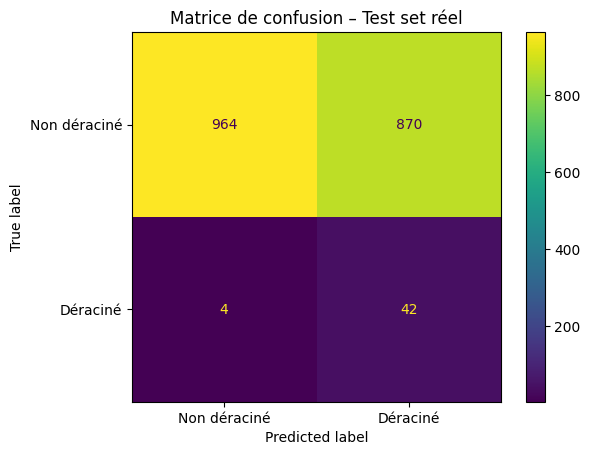

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_s)

print(classification_report(y_test, y_pred, target_names=['Non déraciné', 'Déraciné']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non déraciné', 'Déraciné'])
disp.plot()
plt.title('Matrice de confusion – Test set réel')
plt.show()

**Interprétation des résultats :**

Le modèle détecte **91% des arbres déracinés** sur le test set réel. En contrepartie, la précision sur cette classe est faible (beaucoup de fausses alertes), ce qui se traduit par une accuracy globale plus basse (~54%).

Ce compromis est volontaire et cohérent avec l'objectif : mieux vaut inspecter 100 arbres pour en sécuriser 42 que laisser 4 tomber sans alerte.

**Pourquoi l'accuracy globale est-elle basse ?**
L'accuracy n'est pas une bonne métrique pour un problème très déséquilibré. Un modèle qui prédirait 'non déraciné' pour tous les arbres aurait 97% d'accuracy mais serait totalement inutile pour une alerte. Le recall sur la classe positive est la métrique pertinente ici.

**Limites :** les performances sont contraintes par le faible nombre de cas positifs réels dans les données (~376 sur 11 248). L'ajout de données météorologiques (vitesse/direction du vent) ou d'informations sur l'état sanitaire des arbres améliorerait significativement les résultats.

## 6. Sauvegarde des modèles

On sauvegarde le modèle, le scaler et les encodeurs en fichiers `.pkl`. Le script final les chargera directement sans relancer l'entraînement, conformément aux exigences du projet.

In [11]:
import joblib

joblib.dump(best_model, 'besoin3_model.pkl')
joblib.dump(scaler,     'besoin3_scaler.pkl')
joblib.dump(encoders,   'besoin3_encoders.pkl')

print('Modèles sauvegardés.')

Modèles sauvegardés.
